In [2]:
import pandas as pd
import seaborn as sns
import os

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
base = os.path.join(os.getcwd(),'..','compiled values')

In [5]:
gpp_grp = os.path.join(base,'trends')
os.makedirs(gpp_grp,exist_ok=True)

In [6]:
def gen_index(df):
    if 'month' not in df.columns:
        df['month']=1
    if 'date' in df.columns:
        df['month']=df['date'].apply(lambda x:x.month)
        df['year']=df['date'].apply(lambda x:x.year)
        df.drop(columns=['date'],inplace=True)
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'],inplace=True)
    df['ival']=df['State_Name']+'-'+df['year'].astype(str)+'-'+df['month'].astype(str)
    df.drop(columns=['State_Name','year', 'month'],inplace=True)
    return df

In [7]:
def prepare_dataset(df1,df2,df3):
    df1 = gen_index(df1)
    df2 = gen_index(df2)
    df3 = gen_index(df3)
    df_compiled = pd.merge(df1,df2,on='ival')
    df_compiled = pd.merge(df_compiled,df3,on='ival')
    df_compiled['year']=df_compiled['ival'].apply(lambda x:int(x.split('-')[1]))
    df_compiled['month']=df_compiled['ival'].apply(lambda x:int(x.split('-')[2]))
    df_compiled['State']=df_compiled['ival'].apply(lambda x:(x.split('-')[0]))
    df_compiled_iowa = df_compiled[df_compiled['State']=='IOWA']
    return df_compiled_iowa

In [8]:
lp_cso_ir = pd.read_excel(os.path.join(base,'C_so_pft_irrigated_compiled.xlsx'))
lp_cso_rf = pd.read_excel(os.path.join(base,'C_so_pft_rainfed_compiled.xlsx'))
rs_gpp = pd.read_excel(os.path.join(base,'rs_gpp_compiled.xlsx'))

In [9]:
lp_cso_ir.rename(columns={'Mean(SO)':'SO(IR)'},inplace=True)
lp_cso_rf.rename(columns={'Mean(SO)':'SO(RF)'},inplace=True)
rs_gpp.rename(columns={'mean':'GPP(RS)'},inplace=True)

In [10]:
df_cso = prepare_dataset(lp_cso_ir,lp_cso_rf,rs_gpp)

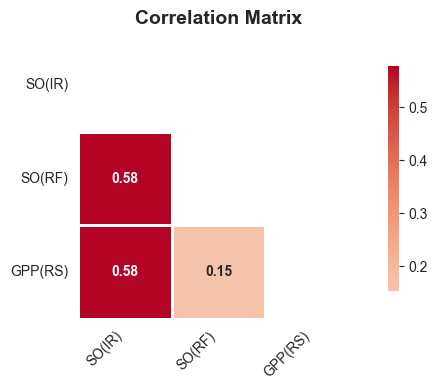

In [73]:
df_cso_sub = df_cso[['SO(IR)','SO(RF)','GPP(RS)']].corr()
mask = np.triu(np.ones_like(df_cso_sub, dtype=bool))

sns.set_style("white")

fig, ax = plt.subplots(figsize=(6,4))

sns.heatmap(
    df_cso_sub,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"size":10, "weight":"bold"},
    cbar_kws={"shrink":0.8},
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=14, weight="bold", pad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)
fn = os.path.join(gpp_grp,'Heatmap_cso_gpp.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

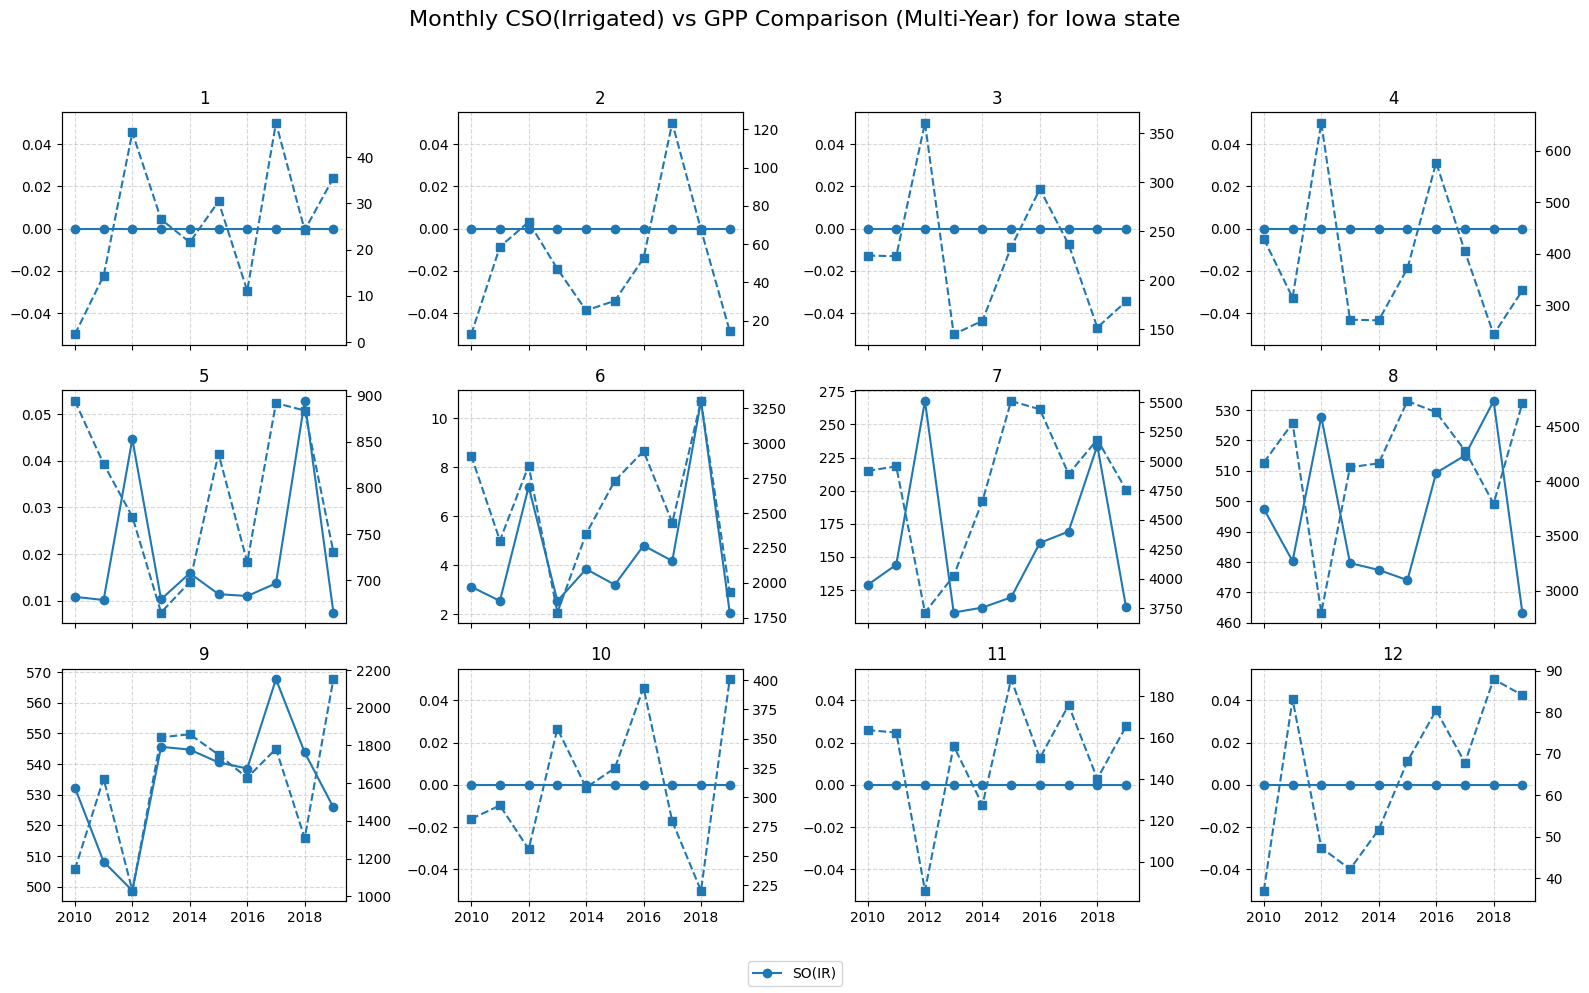

In [15]:
months = np.arange(1,13)

fig, axes = plt.subplots(3, 4, figsize=(16,10), sharex=True)

axes = axes.flatten()
df=df_cso.copy()
for i, month in enumerate(months):
    
    month_data = df[df["month"] == month]
    
    ax1 = axes[i]
    ax1.plot(month_data["year"], month_data["SO(IR)"], marker='o', label="SO(IR)")
    ax1.set_title(month)
    
    ax2 = ax1.twinx()
    ax2.plot(month_data["year"], month_data["GPP(RS)"], 
             marker='s', linestyle='--', label="GPP(RS)")
    
    ax1.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Monthly CSO(Irrigated) vs GPP Comparison (Multi-Year) for Iowa state", fontsize=16)

lines, labels = axes[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="lower center", ncol=2)

fn = os.path.join(gpp_grp,'Trend_cso(ir)_gpp(rs).png')
plt.savefig(fn, bbox_inches='tight',dpi=600)
plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

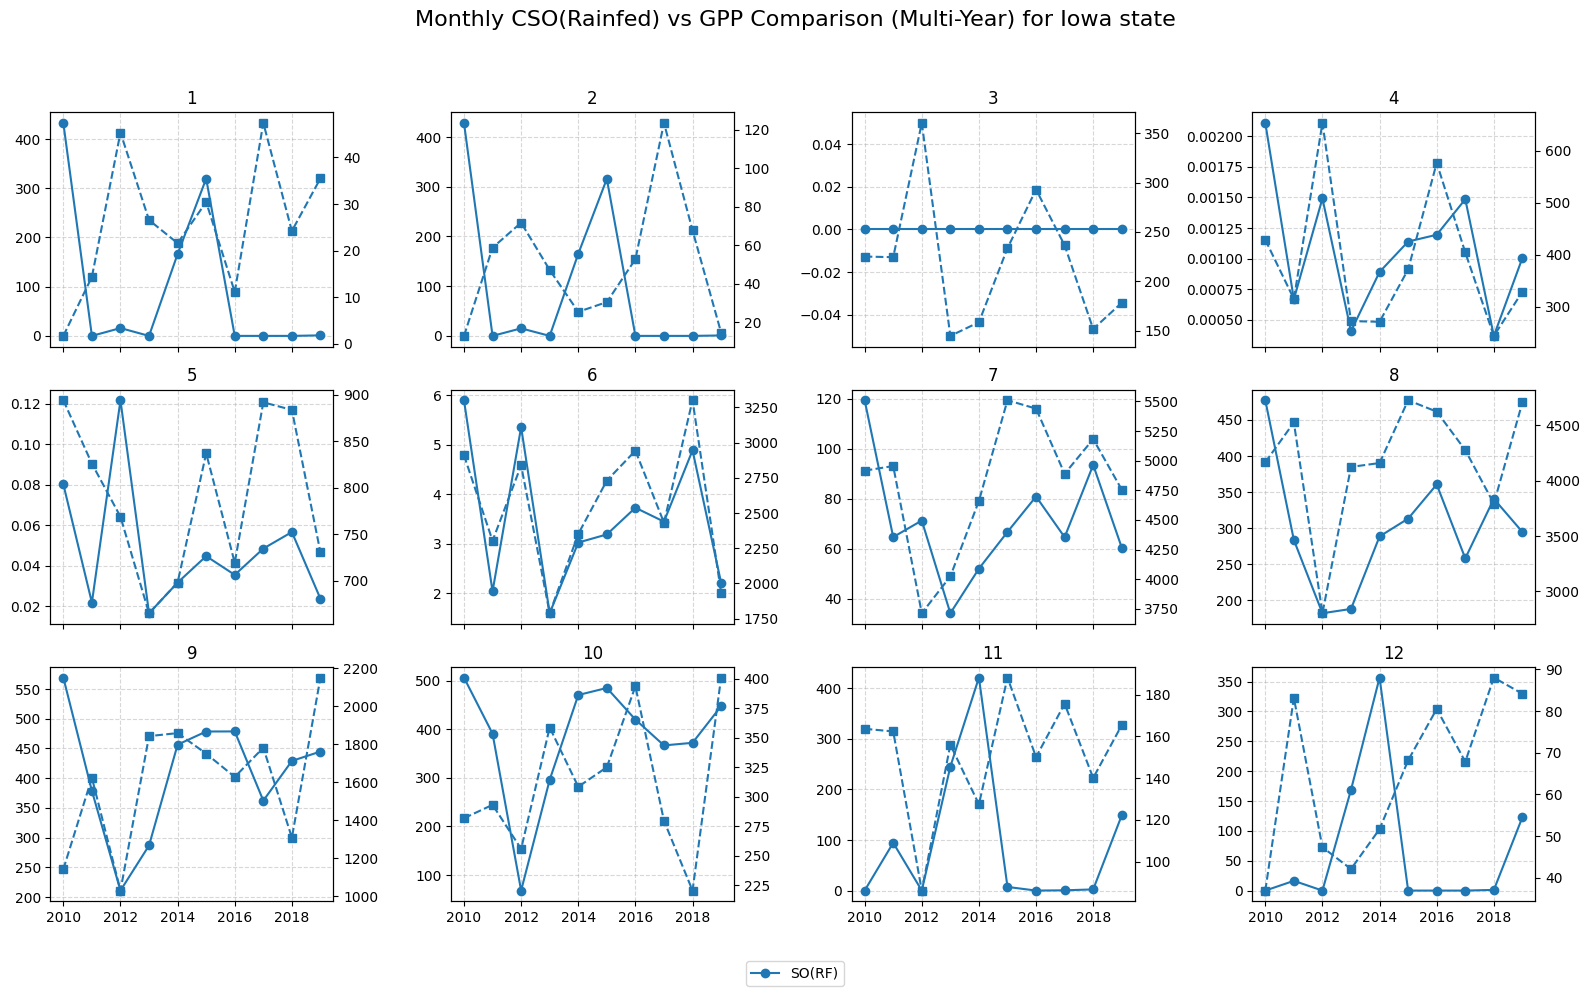

In [16]:
months = np.arange(1,13)

fig, axes = plt.subplots(3, 4, figsize=(16,10), sharex=True)

axes = axes.flatten()
df=df_cso.copy()
for i, month in enumerate(months):
    
    month_data = df[df["month"] == month]
    
    ax1 = axes[i]
    ax1.plot(month_data["year"], month_data["SO(RF)"], marker='o', label="SO(RF)")
    ax1.set_title(month)
    
    ax2 = ax1.twinx()
    ax2.plot(month_data["year"], month_data["GPP(RS)"], 
             marker='s', linestyle='--', label="GPP(RS)")
    
    ax1.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Monthly CSO(Rainfed) vs GPP Comparison (Multi-Year) for Iowa state", fontsize=16)

lines, labels = axes[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="lower center", ncol=2)

fn = os.path.join(gpp_grp,'Trend_cso(rf)_gpp(rs).png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

In [11]:
lp_abgm_ir = pd.read_excel(os.path.join(base,'aboveground_biomassc_irrigated_compiled.xlsx'))
lp_abgm_rf = pd.read_excel(os.path.join(base,'aboveground_biomassc_rainfed_compiled.xlsx'))
rs_yield = pd.read_excel(os.path.join(base,'CASA_yield.xlsx'))

In [12]:
lp_abgm_ir.rename(columns={'Mean(SO)':'AGBM(IR)'},inplace=True)
lp_abgm_rf.rename(columns={'Mean(SO)':'AGBM(RF)'},inplace=True)
rs_yield.rename(columns={'RS_yield':'Yield(RS)'},inplace=True)

In [13]:
df_yield = prepare_dataset(lp_abgm_ir,lp_abgm_rf,rs_yield)

In [14]:
df_yield.columns

Index(['AGBM(IR)', 'ival', 'AGBM(RF)', 'Yield(RS)', 'year', 'month', 'State'], dtype='object')

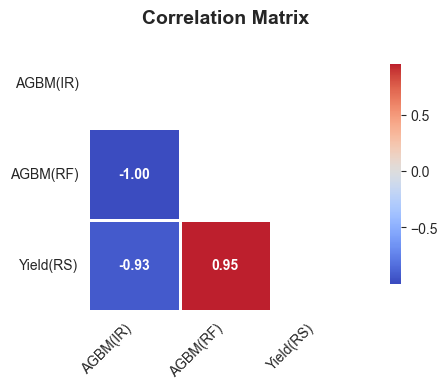

In [77]:
df_yield = df_yield[['AGBM(IR)','AGBM(RF)', 'Yield(RS)']].corr()
mask = np.triu(np.ones_like(df_cso_sub, dtype=bool))

sns.set_style("white")

fig, ax = plt.subplots(figsize=(6,4))

sns.heatmap(
    df_yield,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"size":10, "weight":"bold"},
    cbar_kws={"shrink":0.8},
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=14, weight="bold", pad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)
fn = os.path.join(gpp_grp,'Heatmap_agbm_casa.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

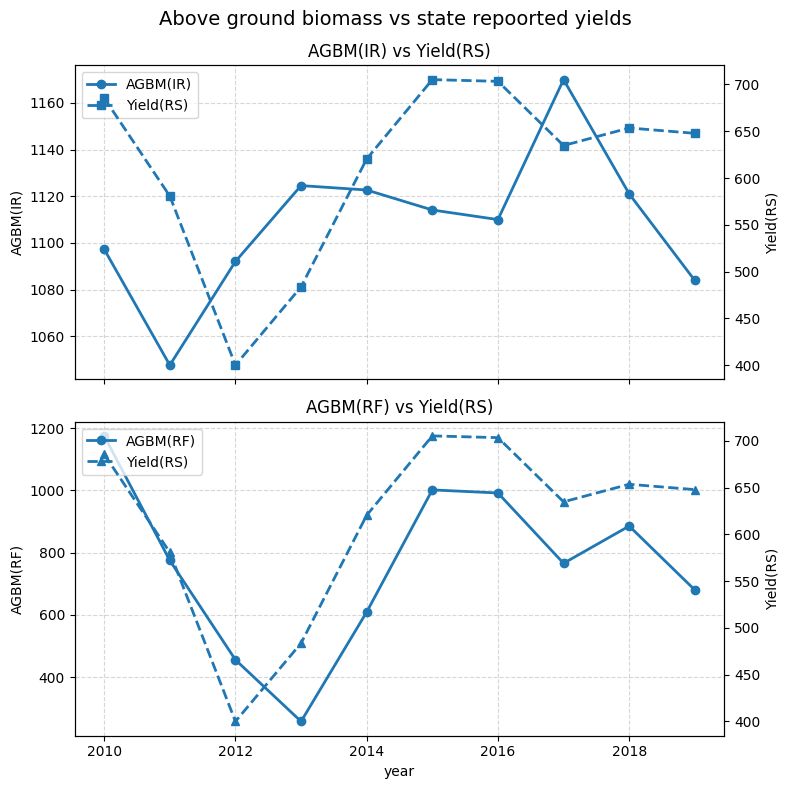

In [15]:
df = df_yield.copy()
df["year"] = df["year"].astype(int)

fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

ax1 = axes[0]
ax1.plot(df["year"], df["AGBM(IR)"], marker='o', linewidth=2, label="AGBM(IR)")
ax1.set_ylabel("AGBM(IR)")

ax1b = ax1.twinx()
ax1b.plot(df["year"], df["Yield(RS)"], marker='s', linestyle='--', linewidth=2, label="Yield(RS)")
ax1b.set_ylabel("Yield(RS)")

ax1.set_title("AGBM(IR) vs Yield(RS)")
ax1.grid(True, linestyle="--", alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax2 = axes[1]
ax2.plot(df["year"], df["AGBM(RF)"], marker='o', linewidth=2, label="AGBM(RF)")
ax2.set_ylabel("AGBM(RF)")
ax2.set_xlabel("year")


ax2b = ax2.twinx()
ax2b.plot(df["year"], df["Yield(RS)"], marker='^', linestyle='--', linewidth=2, label="Yield(RS)")
ax2b.set_ylabel("Yield(RS)")

ax2.set_title("AGBM(RF) vs Yield(RS)")
ax2.grid(True, linestyle="--", alpha=0.5)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.suptitle("Above ground biomass vs state repoorted yields", fontsize=14)

fn = os.path.join(gpp_grp,'Trend_agbm_vs_rs(casa).png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

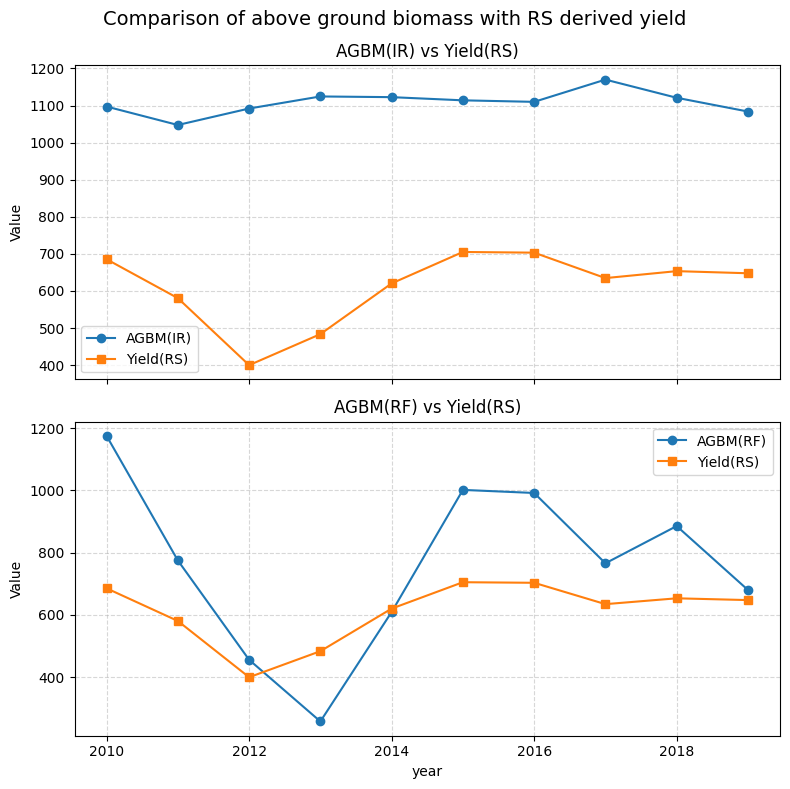

In [26]:
df = df_yield.copy()
df["year"] = df["year"].astype(int)

fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

axes[0].plot(df["year"], df["AGBM(IR)"], marker='o', label="AGBM(IR)")
axes[0].plot(df["year"], df["Yield(RS)"], marker='s', label="Yield(RS)")
axes[0].set_ylabel("Value")
axes[0].set_title("AGBM(IR) vs Yield(RS)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(df["year"], df["AGBM(RF)"], marker='o', label="AGBM(RF)")
axes[1].plot(df["year"], df["Yield(RS)"], marker='s', label="Yield(RS)")
axes[1].set_xlabel("year")
axes[1].set_ylabel("Value")
axes[1].set_title("AGBM(RF) vs Yield(RS)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Comparison of above ground biomass with RS derived yield", fontsize=14)

fn = os.path.join(gpp_grp,'Trend_agbm_rsYield.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

In [27]:
lp_lai_ir = pd.read_excel(os.path.join(base,'LAI_irrigated_compiled.xlsx'))
lp_lai_rf = pd.read_excel(os.path.join(base,'LAI_rainfed_compiled.xlsx'))
rs_lai = pd.read_excel(os.path.join(base,'rs_lai_compiled.xlsx'))

In [28]:
lp_lai_ir.rename(columns={'Mean(SO)':'LAI(IR)'},inplace=True)
lp_lai_rf.rename(columns={'Mean(SO)':'LAI(RF)'},inplace=True)
rs_lai.rename(columns={'mean':'LAI(RS)'},inplace=True)
rs_lai['LAI(RS)']=rs_lai['LAI(RS)']*0.1

In [29]:
df_lai = prepare_dataset(lp_lai_ir,lp_lai_rf,rs_lai)

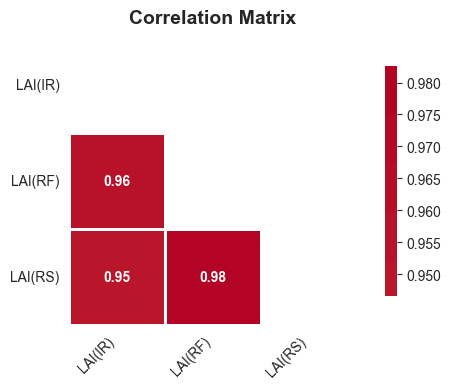

In [78]:
df_lai = df_lai[['LAI(IR)','LAI(RF)', 'LAI(RS)']].corr()
mask = np.triu(np.ones_like(df_cso_sub, dtype=bool))

sns.set_style("white")

fig, ax = plt.subplots(figsize=(6,4))

sns.heatmap(
    df_lai,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"size":10, "weight":"bold"},
    cbar_kws={"shrink":0.8},
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=14, weight="bold", pad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)
fn = os.path.join(gpp_grp,'Heatmap_lai.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

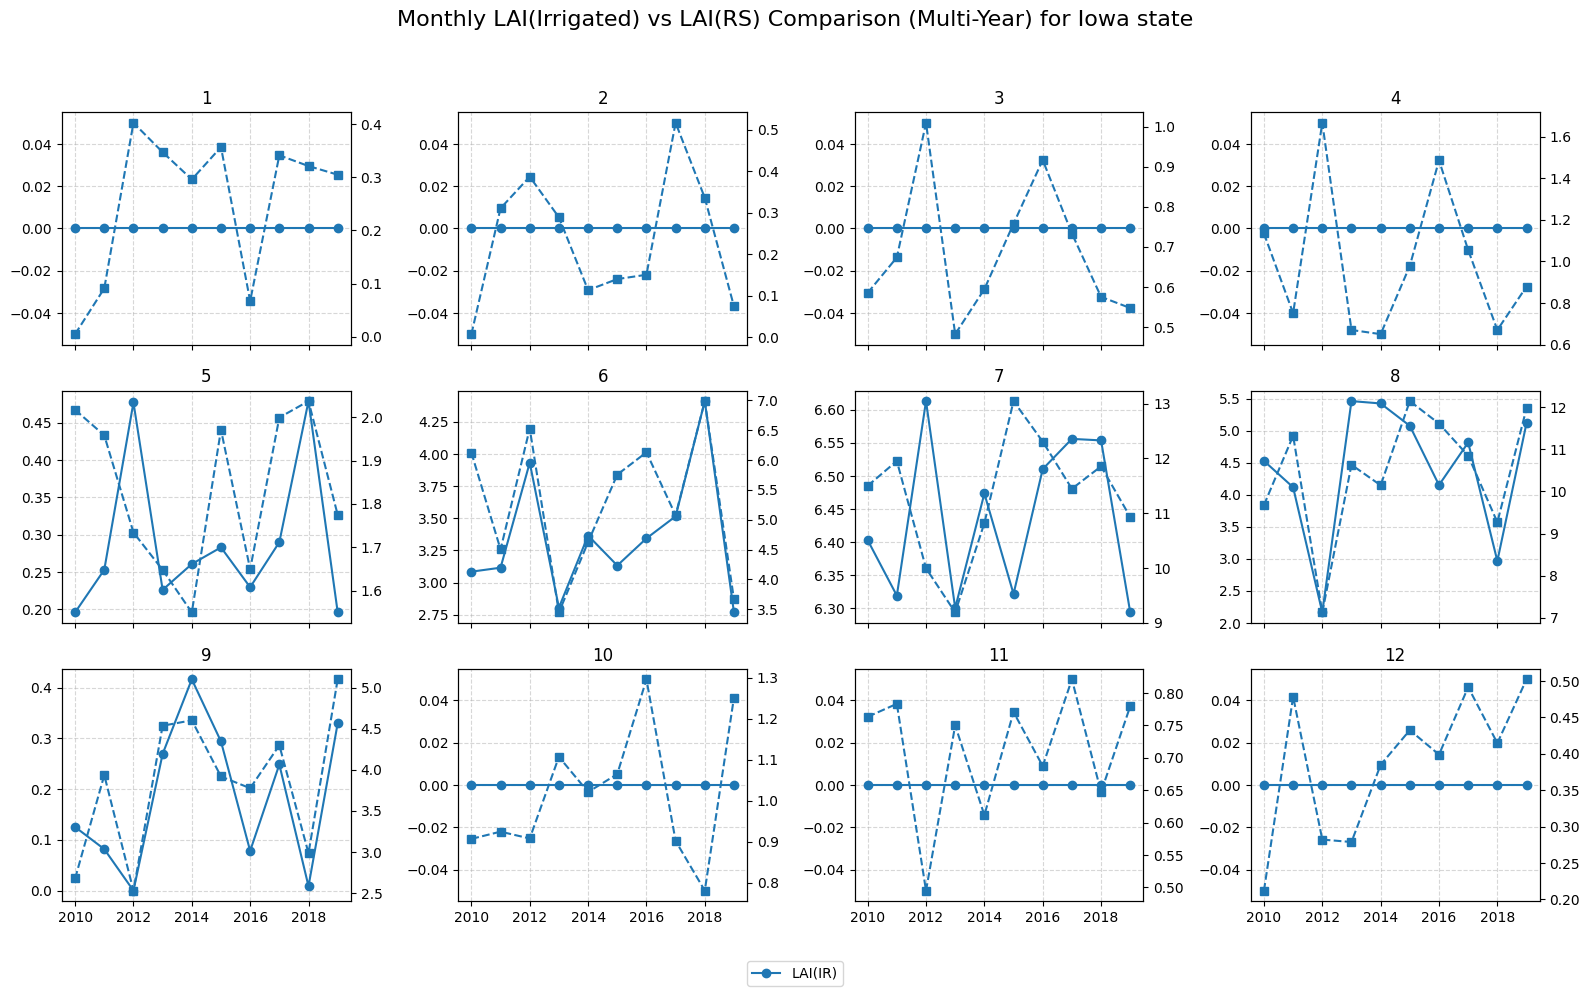

In [32]:
months = np.arange(1,13)

fig, axes = plt.subplots(3, 4, figsize=(16,10), sharex=True)

axes = axes.flatten()
df=df_lai.copy()
for i, month in enumerate(months):
    
    month_data = df[df["month"] == month]
    
    ax1 = axes[i]
    ax1.plot(month_data["year"], month_data["LAI(IR)"], marker='o', label="LAI(IR)")
    ax1.set_title(month)
    
    ax2 = ax1.twinx()
    ax2.plot(month_data["year"], month_data["LAI(RS)"], 
             marker='s', linestyle='--', label="LAI(RS)")
    
    ax1.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Monthly LAI(Irrigated) vs LAI(RS) Comparison (Multi-Year) for Iowa state", fontsize=16)

lines, labels = axes[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="lower center", ncol=2)

fn = os.path.join(gpp_grp,'Trend_lai(ir)_lai(rs).png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

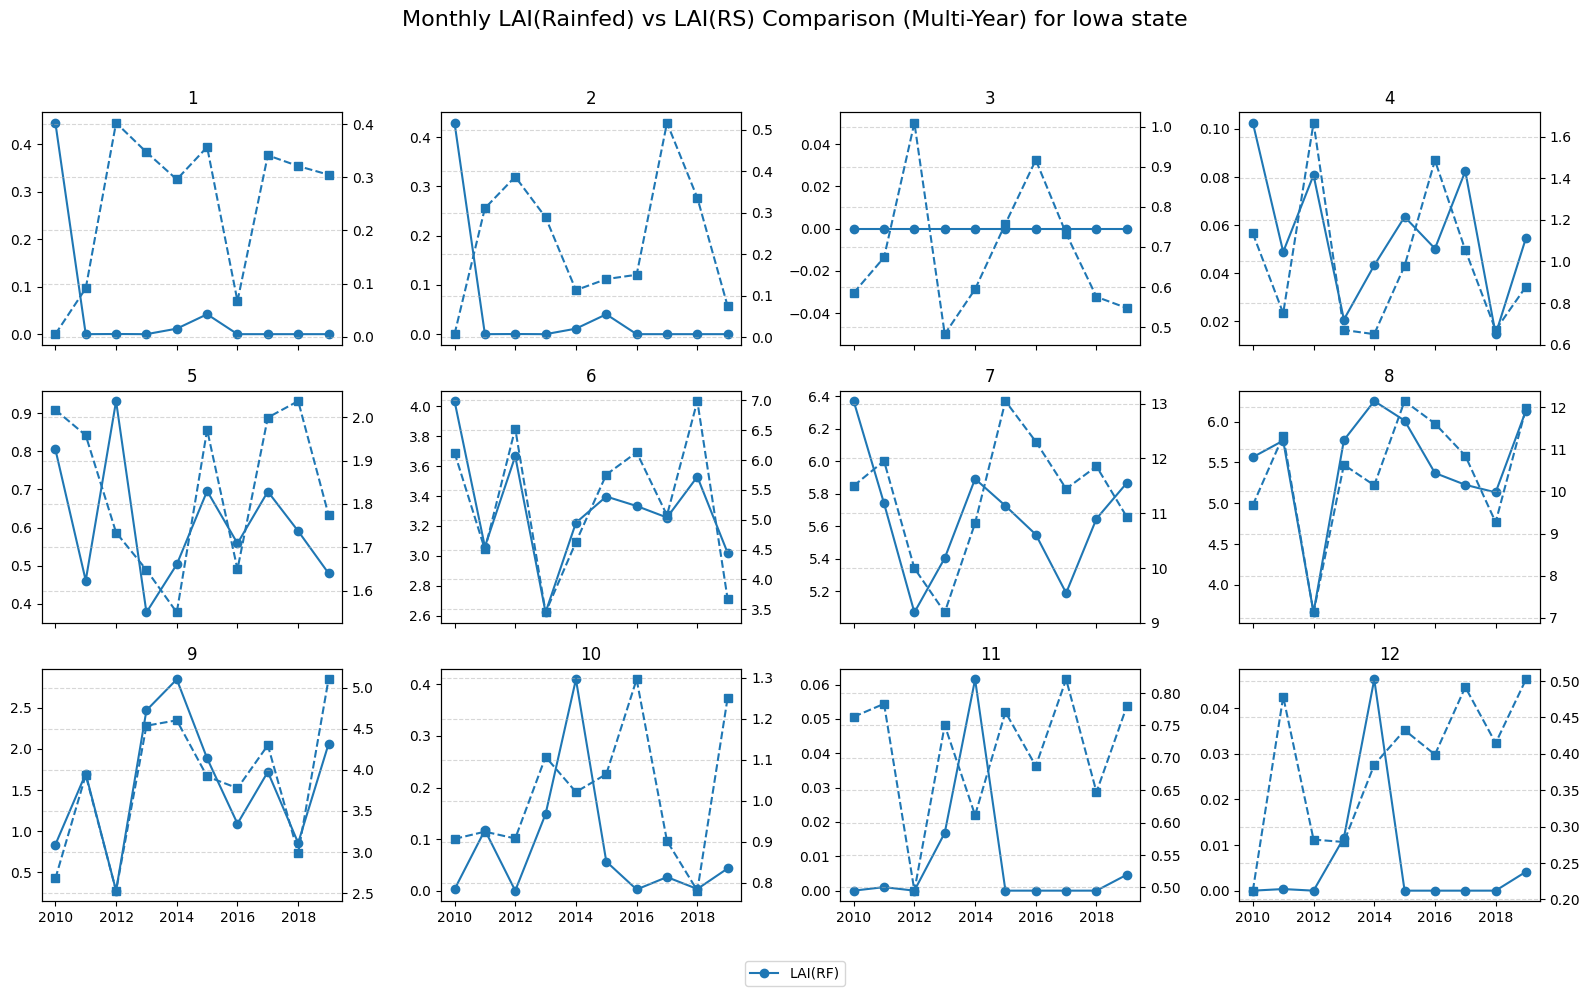

In [34]:
months = np.arange(1,13)

fig, axes = plt.subplots(3, 4, figsize=(16,10), sharex=True)

axes = axes.flatten()
df=df_lai.copy()
for i, month in enumerate(months):
    
    month_data = df[df["month"] == month]
    
    ax1 = axes[i]
    ax1.plot(month_data["year"], month_data["LAI(RF)"], marker='o', label="LAI(RF)")
    ax1.set_title(month)
    
    ax2 = ax1.twinx()
    ax2.plot(month_data["year"], month_data["LAI(RS)"], 
             marker='s', linestyle='--', label="LAI(RS)")
    
    ax2.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Monthly LAI(Rainfed) vs LAI(RS) Comparison (Multi-Year) for Iowa state", fontsize=16)

lines, labels = axes[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="lower center", ncol=2)

fn = os.path.join(gpp_grp,'Trend_lai(rf)_lai(rs).png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

In [35]:
lp_hd_ir = pd.read_excel(os.path.join(base,'hdate_irrigated_compiled.xlsx'))
lp_hd_rf = pd.read_excel(os.path.join(base,'hdate_rainfed_compiled.xlsx'))
rs_hd = pd.read_excel(os.path.join(base,'rs_hdate_clean.xlsx'))

In [36]:
lp_hd_ir.rename(columns={'Mean(SO)':'HD(IR)'},inplace=True)
lp_hd_rf.rename(columns={'Mean(SO)':'HD(RF)'},inplace=True)
rs_hd.rename(columns={'mean':'HD(RS)'},inplace=True)

In [37]:
df_hd = prepare_dataset(lp_hd_ir,lp_hd_rf,rs_hd)

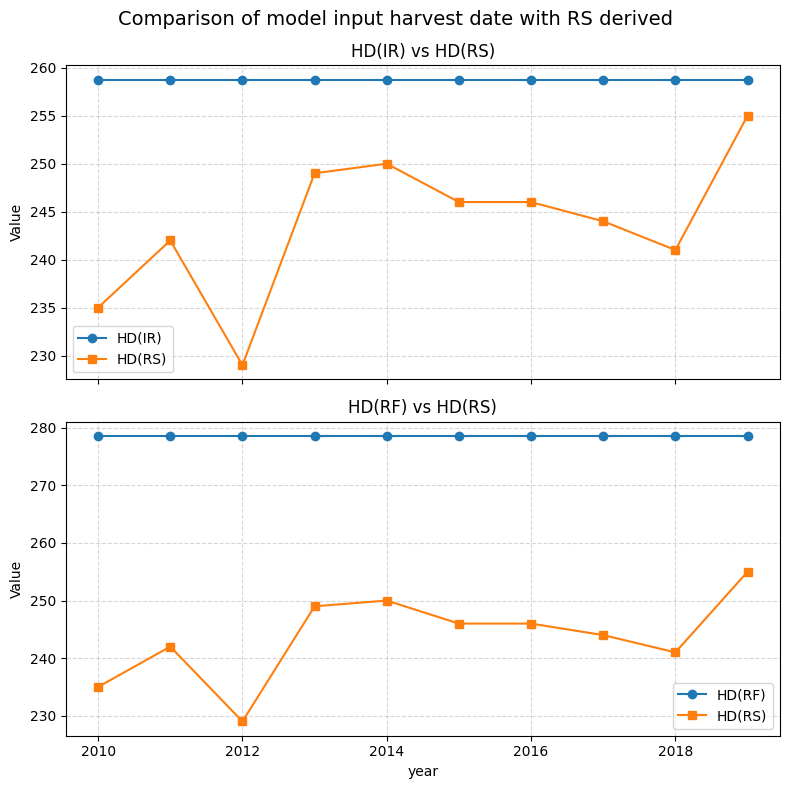

In [39]:
df = df_hd.copy()
df["year"] = df["year"].astype(int)

fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

axes[0].plot(df["year"], df["HD(IR)"], marker='o', label="HD(IR)")
axes[0].plot(df["year"], df["HD(RS)"], marker='s', label="HD(RS)")
axes[0].set_ylabel("Value")
axes[0].set_title("HD(IR) vs HD(RS)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(df["year"], df["HD(RF)"], marker='o', label="HD(RF)")
axes[1].plot(df["year"], df["HD(RS)"], marker='s', label="HD(RS)")
axes[1].set_xlabel("year")
axes[1].set_ylabel("Value")
axes[1].set_title("HD(RF) vs HD(RS)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Comparison of model input harvest date with RS derived", fontsize=14)

fn = os.path.join(gpp_grp,'Trend_hd_rsHD.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

In [46]:
lp_sd_ir = pd.read_excel(os.path.join(base,'sdate_irrigated_compiled.xlsx'))
lp_sd_rf = pd.read_excel(os.path.join(base,'sdate_rainfed_compiled.xlsx'))
rs_sd = pd.read_excel(os.path.join(base,'rs_sdate_clean.xlsx'))

In [47]:
lp_sd_ir.rename(columns={'Mean(SO)':'SD(IR)'},inplace=True)
lp_sd_rf.rename(columns={'Mean(SO)':'SD(RF)'},inplace=True)
rs_sd.rename(columns={'mean':'SD(RS)'},inplace=True)

In [48]:
df_sd = prepare_dataset(lp_sd_ir,lp_sd_rf,rs_sd)

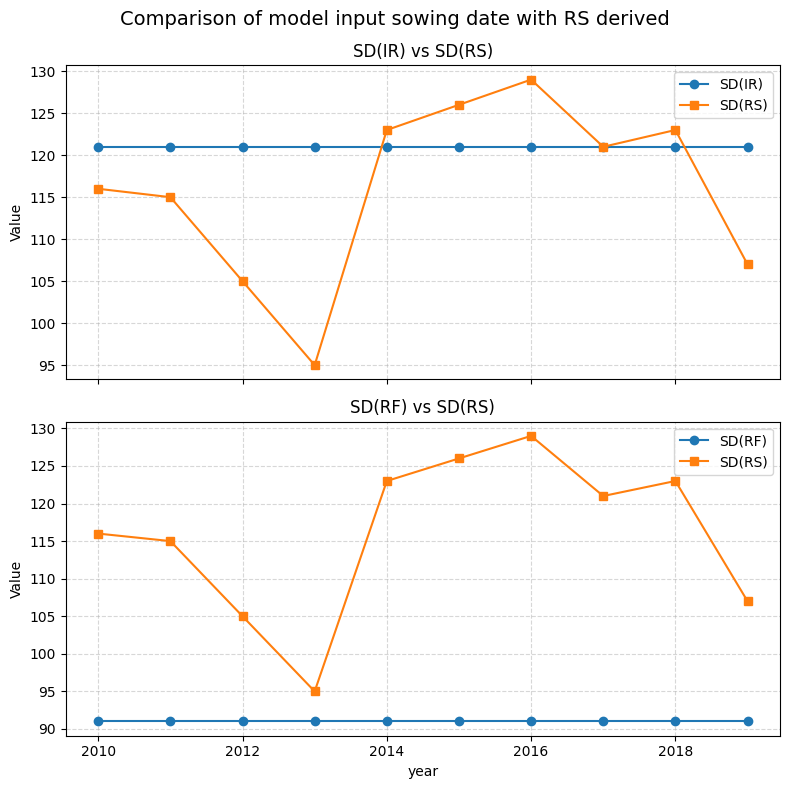

In [52]:
df = df_sd.copy()
df["year"] = df["year"].astype(int)

fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

axes[0].plot(df["year"], df["SD(IR)"], marker='o', label="SD(IR)")
axes[0].plot(df["year"], df["SD(RS)"], marker='s', label="SD(RS)")
axes[0].set_ylabel("Value")
axes[0].set_title("SD(IR) vs SD(RS)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(df["year"], df["SD(RF)"], marker='o', label="SD(RF)")
axes[1].plot(df["year"], df["SD(RS)"], marker='s', label="SD(RS)")
axes[1].set_xlabel("year")
axes[1].set_ylabel("Value")
axes[1].set_title("SD(RF) vs SD(RS)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Comparison of model input sowing date with RS derived", fontsize=14)

fn = os.path.join(gpp_grp,'Trend_sd_rsSD.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

In [53]:
lp_abgm_ir = pd.read_excel(os.path.join(base,'aboveground_biomassc_irrigated_compiled.xlsx'))
lp_abgm_rf = pd.read_excel(os.path.join(base,'aboveground_biomassc_rainfed_compiled.xlsx'))
yield_data = pd.read_excel(os.path.join(base,'Corn_apy_data.xlsx'))

In [55]:
yield_data = yield_data[['YEAR', 'LOCATION','YIELD in BU / ACRE']]

In [57]:
yield_data.rename(columns={'LOCATION':'State_Name'},inplace=True)
yield_data['date']=pd.to_datetime(yield_data['YEAR'],format='%Y')
yield_data.drop(columns=['YEAR'],inplace=True)

In [58]:
lp_abgm_ir.rename(columns={'Mean(SO)':'AGBM(IR)'},inplace=True)
lp_abgm_rf.rename(columns={'Mean(SO)':'AGBM(RF)'},inplace=True)

In [59]:
df_yld = prepare_dataset(lp_abgm_ir,lp_abgm_rf,yield_data)

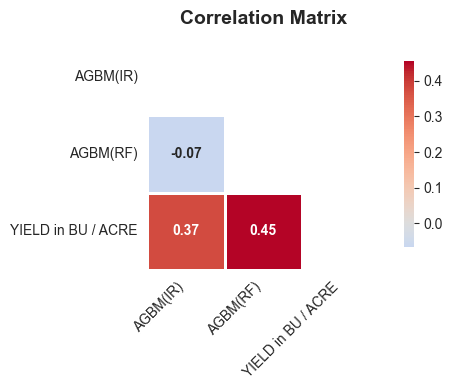

In [80]:
df_yld = df_yld[['AGBM(IR)','AGBM(RF)', 'YIELD in BU / ACRE']].corr()
mask = np.triu(np.ones_like(df_cso_sub, dtype=bool))

sns.set_style("white")

fig, ax = plt.subplots(figsize=(6,4))

sns.heatmap(
    df_yld,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"size":10, "weight":"bold"},
    cbar_kws={"shrink":0.8},
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=14, weight="bold", pad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)
fn = os.path.join(gpp_grp,'Heatmap_agbm_state.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()

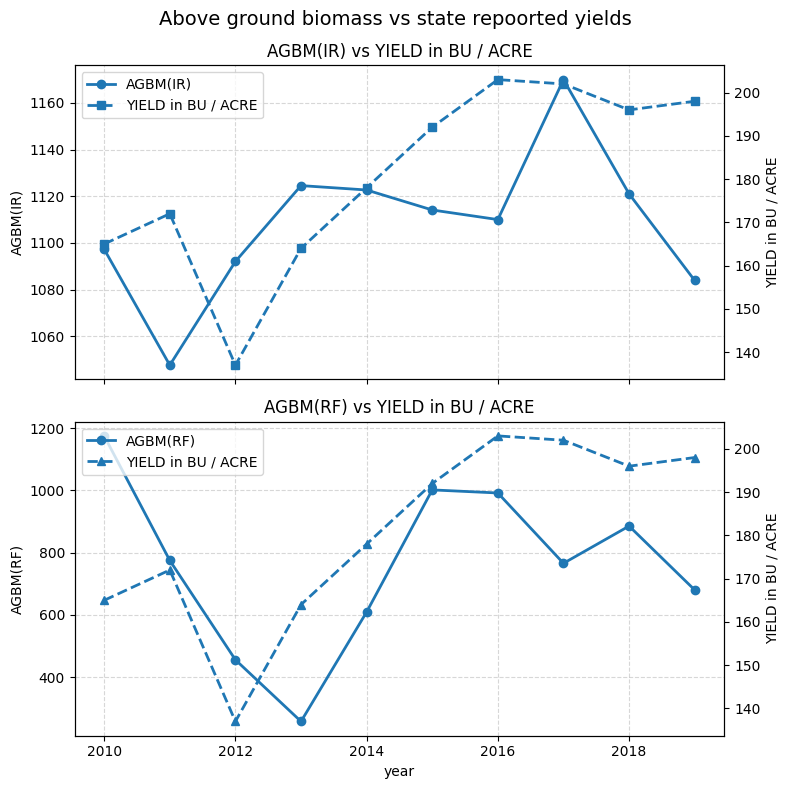

In [62]:
df = df_yld.copy()
df["year"] = df["year"].astype(int)

fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

ax1 = axes[0]
ax1.plot(df["year"], df["AGBM(IR)"], marker='o', linewidth=2, label="AGBM(IR)")
ax1.set_ylabel("AGBM(IR)")

ax1b = ax1.twinx()
ax1b.plot(df["year"], df["YIELD in BU / ACRE"], marker='s', linestyle='--', linewidth=2, label="YIELD in BU / ACRE")
ax1b.set_ylabel("YIELD in BU / ACRE")

ax1.set_title("AGBM(IR) vs YIELD in BU / ACRE")
ax1.grid(True, linestyle="--", alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax2 = axes[1]
ax2.plot(df["year"], df["AGBM(RF)"], marker='o', linewidth=2, label="AGBM(RF)")
ax2.set_ylabel("AGBM(RF)")
ax2.set_xlabel("year")


ax2b = ax2.twinx()
ax2b.plot(df["year"], df["YIELD in BU / ACRE"], marker='^', linestyle='--', linewidth=2, label="YIELD in BU / ACRE")
ax2b.set_ylabel("YIELD in BU / ACRE")

ax2.set_title("AGBM(RF) vs YIELD in BU / ACRE")
ax2.grid(True, linestyle="--", alpha=0.5)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.suptitle("Above ground biomass vs state repoorted yields", fontsize=14)

fn = os.path.join(gpp_grp,'Trend_agbm_vs_state.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()